# Fraud Detection

In [1]:
# Setup - Imports
import os
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    import xgboost as xgb
except:
    xgb = None

import joblib
print("Setup Complete")

Setup Complete


In [2]:
# loading data
DATA_PATH = "Fraud.csv"
assert os.path.exists(DATA_PATH), 'Dataset Not Found'
df = pd.read_csv(DATA_PATH)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
# Quick EDA (Exploratory Data Analysis)
print("Shape:", df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['isFraud'].value_counts())
print("Fraud Ratio:", df['isFraud'].mean())

Shape: (6362620, 11)
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud Ratio: 0.001290820448180152


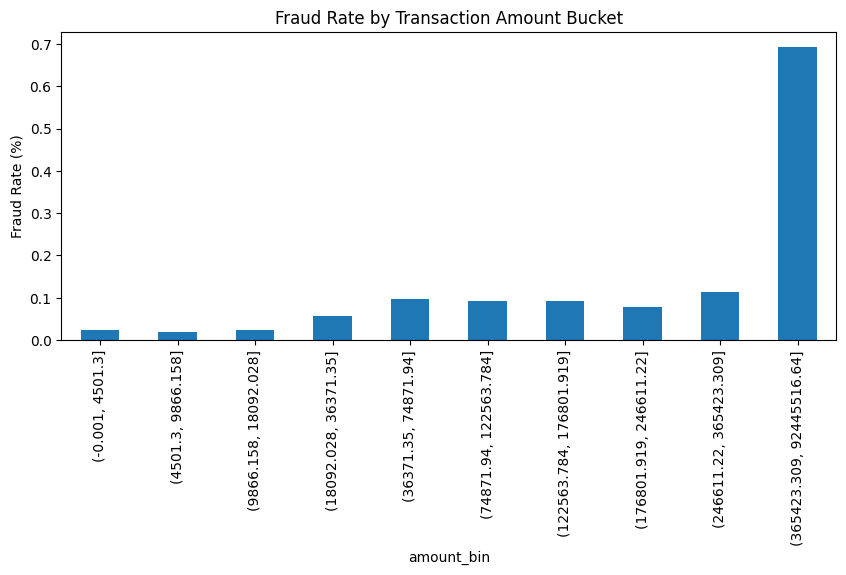

In [4]:
# Fraud Rate by Amount Bucket
df['amount_bin'] = pd.qcut(df['amount'], q=10, duplicates='drop')

fraud_rate = df.groupby('amount_bin')['isFraud'].mean()
fraud_rate = fraud_rate*100

plt.figure(figsize=(10,4))
fraud_rate.plot(kind='bar')
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Amount Bucket")

plt.show()

This analysis demonstrates that transaction amount is not just a magnitude feature but a strong risk indicator, with fraud likelihood increasing significantly in higher value transaction buckets

In [5]:
# Checking missing values
df.isnull().sum()

# Creating merchant transactions (destination starting with 'M')
merchant_txns = df[df['nameDest'].str.startswith('M')]

merchant_txns[['oldbalanceDest', 'newbalanceDest']].describe()

,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


No imputation performed as Zeros represent valid merchant behaviour, not missing data

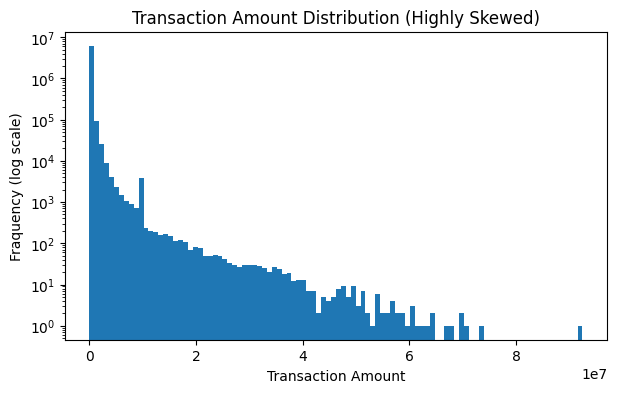

In [6]:
# Outlier Handling
df['amount'].describe()

# Visualize Skewness

plt.figure(figsize=(7,4))
plt.hist(df['amount'], bins=100)
plt.yscale('log')
plt.xlabel('Transaction Amount')
plt.ylabel('Fraquency (log scale)')
plt.title('Transaction Amount Distribution (Highly Skewed)')
plt.show()